# Практика: статистический анализ аномалий во временных рядах

**Датасет:** еженедельное энергопотребление, ветер, солнце — Германия  
**Методы:** только статистика, без ML/DL  
**Бейслайн:** MSTL + доверительный интервал 99% (уже готов в коде ниже)

---
| # | Метод | Идея |
|---|---|---|
| 1 | MSTL CI-99 | предсказание + границы (бейслайн) |
| 2 | Rolling Z-score | отклонение от скользящего среднего |
| 3 | IQR | межквартильный размах |
| 4 | STL residuals | остаток после декомпозиции |
| 5 | CUSUM | накопленное отклонение от целевого уровня |
| 6 | Grubbs test | одна аномалия за раз, t-распределение |
| 7 | Ensemble voting | голосование методов 1–5 |

## 0. Установка и импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

## 1. Загрузка данных и бейслайн MSTL

Воспроизводим ваш исходный код без изменений.

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import MSTL

# ---------- загрузка ----------
df = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)

ts       = ['Consumption', 'Wind', 'Solar']
exog_cols = ['temperature', 'radiation_direct_horizontal']

y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind':        'sum',
    'Solar':       'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8
y = y.iloc[1:-2]

base_cols  = ['unique_id', 'ds', 'y']
date_index = y.index
FREQ       = y.index.freq
SEASON     = 52
FH         = int(0.42 * y.shape[0])

panel_list = [pd.DataFrame({'ds': date_index, 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df   = pd.concat(panel_list, ignore_index=True)[base_cols]

df_test  = panel_df.groupby('unique_id').tail(FH)
df_train = panel_df.drop(df_test.index).reset_index(drop=True)

# ---------- MSTL ----------
levels = [99]
models = [MSTL(season_length=[SEASON], alias='MSTL')]
sf     = StatsForecast(models=models, freq=FREQ)

fcst               = sf.forecast(df=df_train, h=FH, level=levels, fitted=True)
insample_forecasts = sf.forecast_fitted_values().drop(columns=['y'])

res_df = panel_df.merge(
    pd.concat([insample_forecasts, fcst]),
    on=['unique_id', 'ds'], how='left'
)

# ---------- бейслайн аномалии ----------
anomalies = res_df[
    ~res_df['y'].between(res_df['MSTL-lo-99'], res_df['MSTL-hi-99'])
][['unique_id', 'ds', 'y']].copy()
anomalies['MSTL_anomaly'] = 1

print(f"Размер датасета: {y.shape}  |  FH={FH}  |  SEASON={SEASON}")
print(f"\nMSTL нашёл аномалий по рядам:")
print(anomalies.groupby('unique_id').size().to_string())

Размер датасета: (259, 5)  |  FH=108  |  SEASON=52

MSTL нашёл аномалий по рядам:
unique_id
Consumption    11
Solar          22
Wind            8


---
## Метод 2 — Rolling Z-score

**Идея:** если значение $y_t$ сильно отклоняется от локального среднего, это аномалия.

$$z_t = \frac{y_t - \bar{y}_{t,w}}{s_{t,w}}$$

где $\bar{y}_{t,w}$ и $s_{t,w}$ — скользящие среднее и std по окну $w$ **до** точки $t$ (shift=1).  
Аномалия: $|z_t| > \text{threshold}$

**Параметры для настройки:**
- `window` — ширина окна (рекомендуется 13 = квартал или 26 = полгода)
- `threshold` — порог (обычно 2.5–3.5; чем ниже → больше флагов)

In [3]:
def rolling_zscore(series: pd.Series, window: int = 13, threshold: float = 3.0) -> pd.DataFrame:
    """
    Rolling Z-score детектор аномалий.

    Параметры
    ----------
    series    : pd.Series с DatetimeIndex
    window    : кол-во точек в скользящем окне
    threshold : порог по абсолютному z-score

    Возвращает
    ----------
    DataFrame: y | roll_mean | roll_std | z_score | anomaly (0/1)
    """
    df = pd.DataFrame({'y': series})
    # shift(1) — не включаем текущую точку, чтобы не «смягчить» выброс
    rolled       = df['y'].shift(1).rolling(window, min_periods=window // 2)
    df['roll_mean'] = rolled.mean()
    df['roll_std']  = rolled.std()
    df['z_score']   = (df['y'] - df['roll_mean']) / df['roll_std']
    df['anomaly']   = (df['z_score'].abs() > threshold).astype(int)
    return df.dropna()


# --- запускаем для всех трёх рядов ---
zscore_res = {col: rolling_zscore(y[col], window=13, threshold=3.0) for col in ts}

for col, r in zscore_res.items():
    print(f"{col}: {r['anomaly'].sum()} аномалий")

Consumption: 13 аномалий
Wind: 8 аномалий
Solar: 17 аномалий


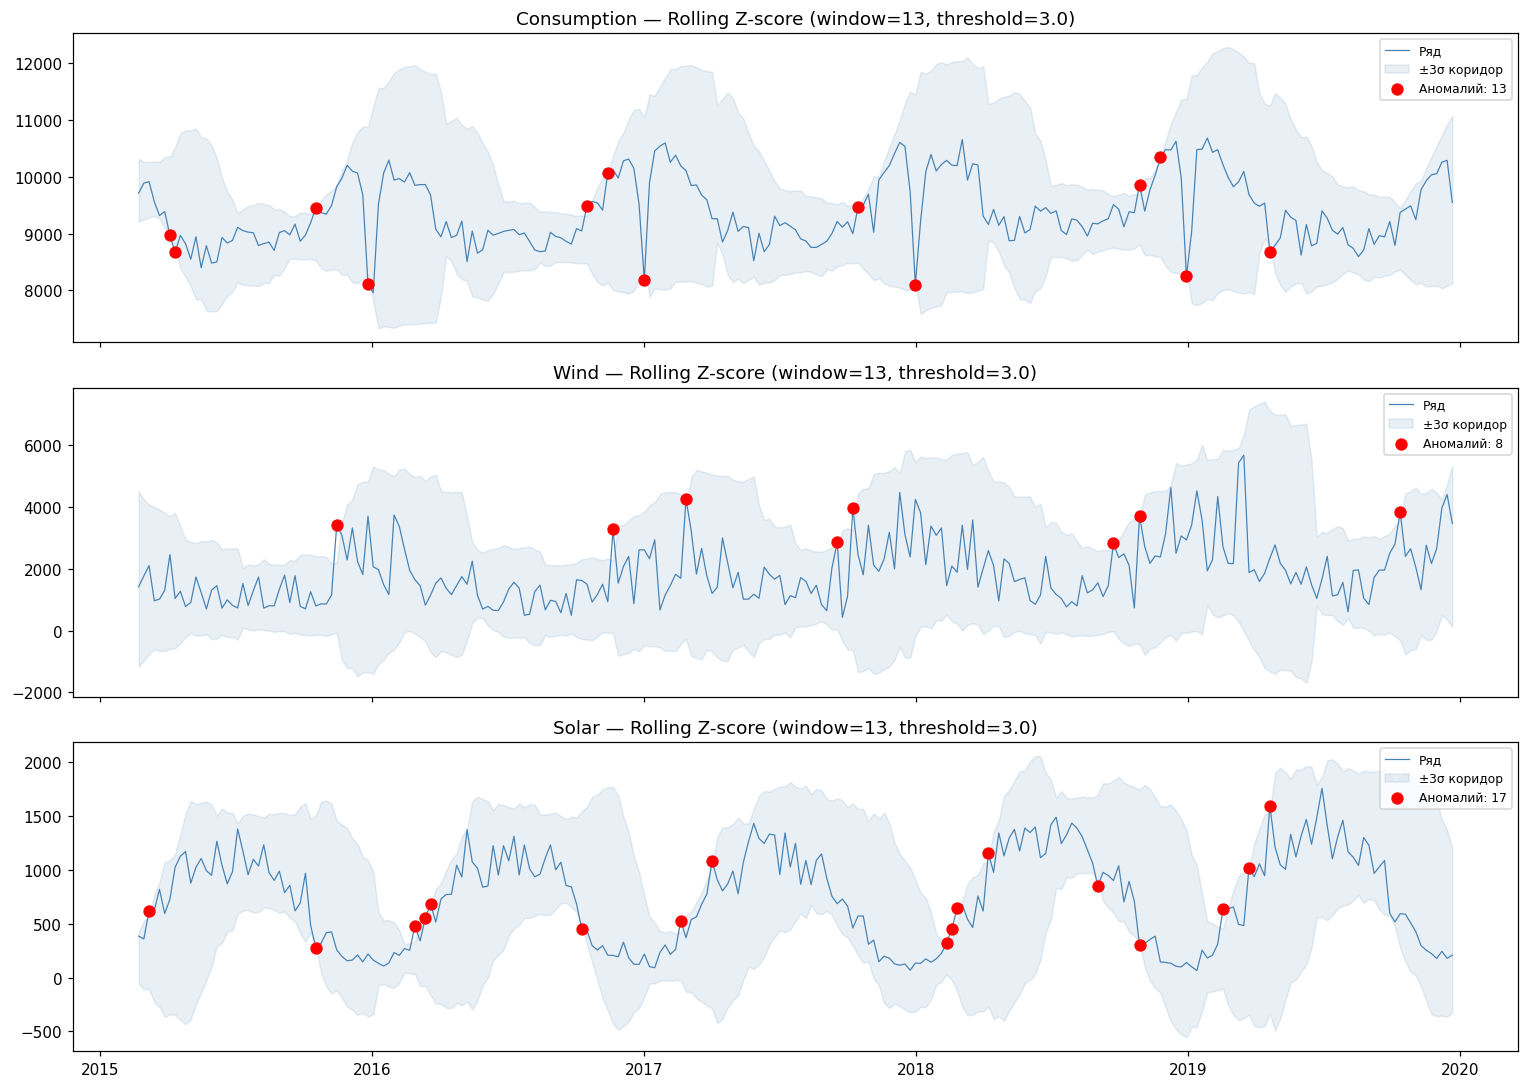

In [4]:
# --- визуализация ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, ts):
    r = zscore_res[col]
    ax.plot(r.index, r['y'], lw=0.8, color='steelblue', label='Ряд')
    ax.fill_between(
        r.index,
        r['roll_mean'] - 3 * r['roll_std'],
        r['roll_mean'] + 3 * r['roll_std'],
        alpha=0.12, color='steelblue', label='±3σ коридор'
    )
    anom = r[r['anomaly'] == 1]
    ax.scatter(anom.index, anom['y'], color='red', s=50, zorder=5, label=f'Аномалий: {len(anom)}')
    ax.set_title(f'{col} — Rolling Z-score (window=13, threshold=3.0)')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('method2_zscore.png', dpi=120)
plt.show()

In [5]:
# --- задание для студентов: как threshold влияет на количество аномалий? ---
print(f"{'threshold':>10} | {'Consumption':>13} | {'Wind':>6} | {'Solar':>6}")
print("-" * 46)
for thr in [2.0, 2.5, 3.0, 3.5, 4.0]:
    counts = {col: rolling_zscore(y[col], window=13, threshold=thr)['anomaly'].sum() for col in ts}
    print(f"{thr:>10.1f} | {counts['Consumption']:>13} | {counts['Wind']:>6} | {counts['Solar']:>6}")

 threshold |   Consumption |   Wind |  Solar
----------------------------------------------
       2.0 |            43 |     20 |     55
       2.5 |            25 |     11 |     30
       3.0 |            13 |      8 |     17
       3.5 |             3 |      3 |      7
       4.0 |             2 |      3 |      6


---
## Метод 3 — IQR (Interquartile Range)

**Идея:** вычислить межквартильный размах, построить «усы» (fence), всё что снаружи — аномалия.

$$\text{lower} = Q_1 - k \cdot IQR, \quad \text{upper} = Q_3 + k \cdot IQR$$

где $IQR = Q_3 - Q_1$, стандартный $k = 1.5$ (мягко) или $k = 3.0$ (строго).

**Важно:** делаем это в скользящем окне, иначе сезонные пики Solar всегда будут «аномалиями».

In [6]:
def rolling_iqr(series: pd.Series, window: int = 26, k: float = 3.0) -> pd.DataFrame:
    """
    Детектор аномалий на основе скользящего IQR.

    Параметры
    ----------
    series : pd.Series
    window : ширина скользящего окна
    k      : множитель IQR (1.5 = мягко, 3.0 = строго)
    """
    df = pd.DataFrame({'y': series})

    # скользящие квантили — shift(1) чтобы не утечки
    rolled = df['y'].shift(1).rolling(window, min_periods=window // 2)
    q1 = rolled.quantile(0.25)
    q3 = rolled.quantile(0.75)
    iqr = q3 - q1

    df['q1']      = q1
    df['q3']      = q3
    df['lower']   = q1 - k * iqr
    df['upper']   = q3 + k * iqr
    df['anomaly'] = (~df['y'].between(df['lower'], df['upper'])).astype(int)
    return df.dropna()


iqr_res = {col: rolling_iqr(y[col], window=26, k=3.0) for col in ts}

for col, r in iqr_res.items():
    print(f"{col}: {r['anomaly'].sum()} аномалий")

Consumption: 8 аномалий
Wind: 3 аномалий
Solar: 0 аномалий


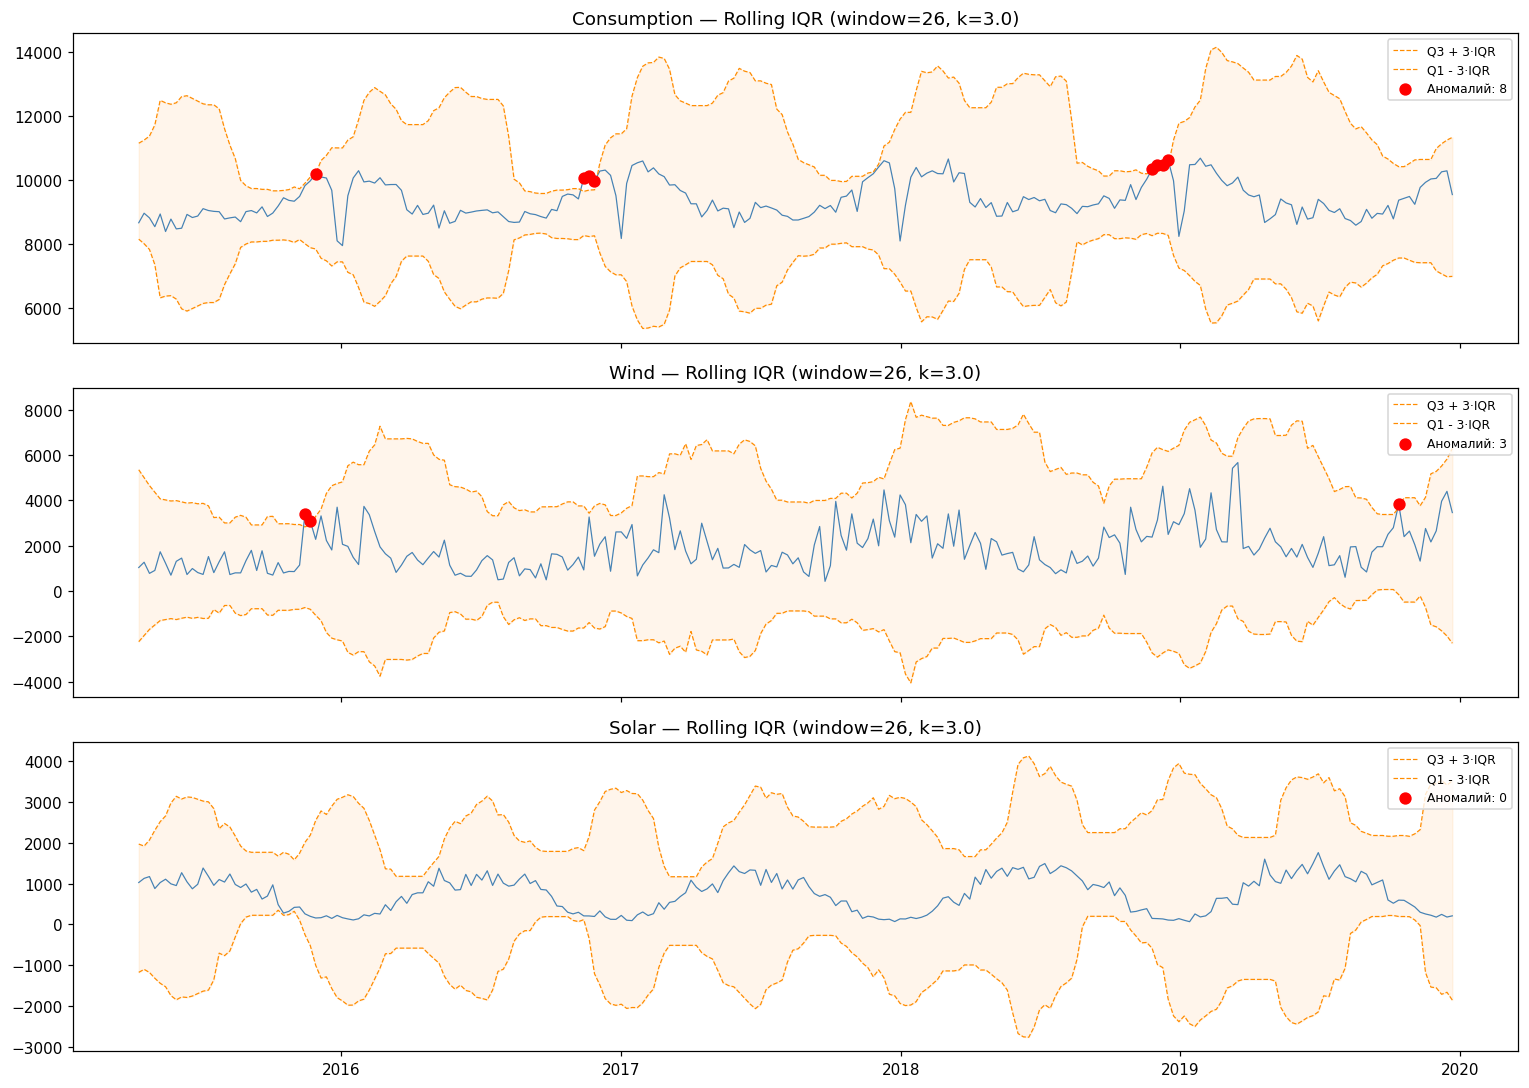

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, ts):
    r = iqr_res[col]
    ax.plot(r.index, r['y'],     lw=0.8, color='steelblue')
    ax.plot(r.index, r['upper'], lw=0.8, color='darkorange', ls='--', label='Q3 + 3·IQR')
    ax.plot(r.index, r['lower'], lw=0.8, color='darkorange', ls='--', label='Q1 - 3·IQR')
    ax.fill_between(r.index, r['lower'], r['upper'], alpha=0.08, color='darkorange')
    anom = r[r['anomaly'] == 1]
    ax.scatter(anom.index, anom['y'], color='red', s=50, zorder=5, label=f'Аномалий: {len(anom)}')
    ax.set_title(f'{col} — Rolling IQR (window=26, k=3.0)')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('method3_iqr.png', dpi=120)
plt.show()

---
## Метод 4 — STL Residuals

**Идея:** STL (Seasonal-Trend decomposition using Loess) разбивает ряд на три части:

$$y_t = T_t + S_t + R_t$$

- $T_t$ — тренд (медленное изменение)
- $S_t$ — сезонность (повторяющийся паттерн)
- $R_t$ — **остаток**: всё, что не объяснено трендом и сезонностью

Аномалия = точка с большим $|R_t|$.  
**Преимущество перед Z-score:** STL не путает сезонный пик (например, Solar летом) с аномалией.

In [8]:
from statsmodels.tsa.seasonal import STL

def stl_residual_anomalies(
    series: pd.Series,
    period: int = 52,
    threshold_sigma: float = 3.0
) -> pd.DataFrame:
    """
    STL-декомпозиция + пороговый остаток.

    Параметры
    ----------
    series          : pd.Series
    period          : сезонный период (52 для недельных данных)
    threshold_sigma : порог в σ остатка
    """
    stl = STL(series, period=period, robust=True)  # robust=True — устойчив к выбросам
    res = stl.fit()

    resid   = pd.Series(res.resid, index=series.index)
    mu, sig = resid.mean(), resid.std()

    result = pd.DataFrame({
        'y':        series,
        'trend':    res.trend,
        'seasonal': res.seasonal,
        'residual': resid,
        'upper':    mu + threshold_sigma * sig,
        'lower':    mu - threshold_sigma * sig,
    })
    result['anomaly'] = (
        (result['residual'] > result['upper']) |
        (result['residual'] < result['lower'])
    ).astype(int)
    return result


stl_res = {col: stl_residual_anomalies(y[col], period=52, threshold_sigma=3.0) for col in ts}

for col, r in stl_res.items():
    print(f"{col}: {r['anomaly'].sum()} аномалий")

Consumption: 4 аномалий
Wind: 5 аномалий
Solar: 8 аномалий


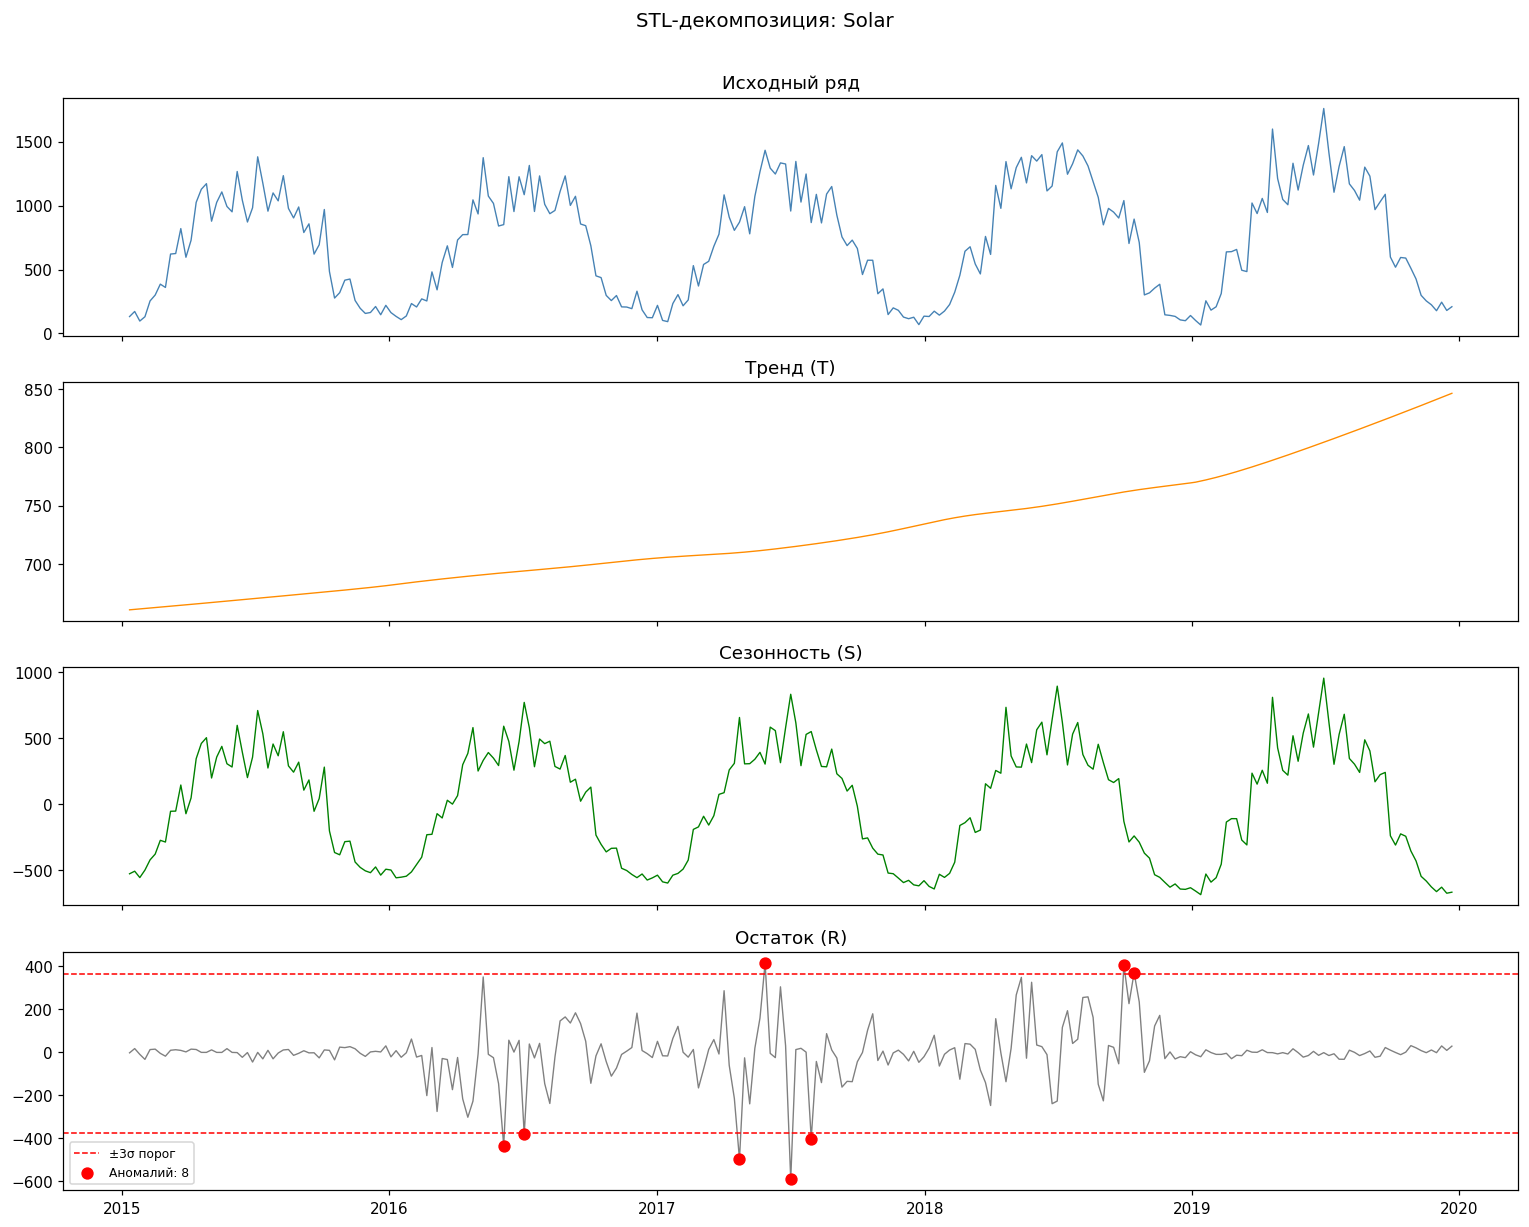

In [9]:
# --- Декомпозиция + остаток для одного ряда ---
col = 'Solar'   # <-- поменяйте на Consumption или Wind
r   = stl_res[col]

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
titles = ['Исходный ряд', 'Тренд (T)', 'Сезонность (S)', 'Остаток (R)']
cols_plot = ['y', 'trend', 'seasonal', 'residual']
colors_plot = ['steelblue', 'darkorange', 'green', 'gray']

for ax, title, c, color in zip(axes, titles, cols_plot, colors_plot):
    ax.plot(r.index, r[c], lw=0.9, color=color)
    ax.set_title(title)

# на графике остатка показываем порог и аномалии
axes[3].axhline(r['upper'].iloc[0], color='red', ls='--', lw=1, label='±3σ порог')
axes[3].axhline(r['lower'].iloc[0], color='red', ls='--', lw=1)
anom = r[r['anomaly'] == 1]
axes[3].scatter(anom.index, anom['residual'], color='red', s=50, zorder=5,
                label=f'Аномалий: {len(anom)}')
axes[3].legend(fontsize=8)

fig.suptitle(f'STL-декомпозиция: {col}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'method4_stl_{col.lower()}.png', dpi=120)
plt.show()

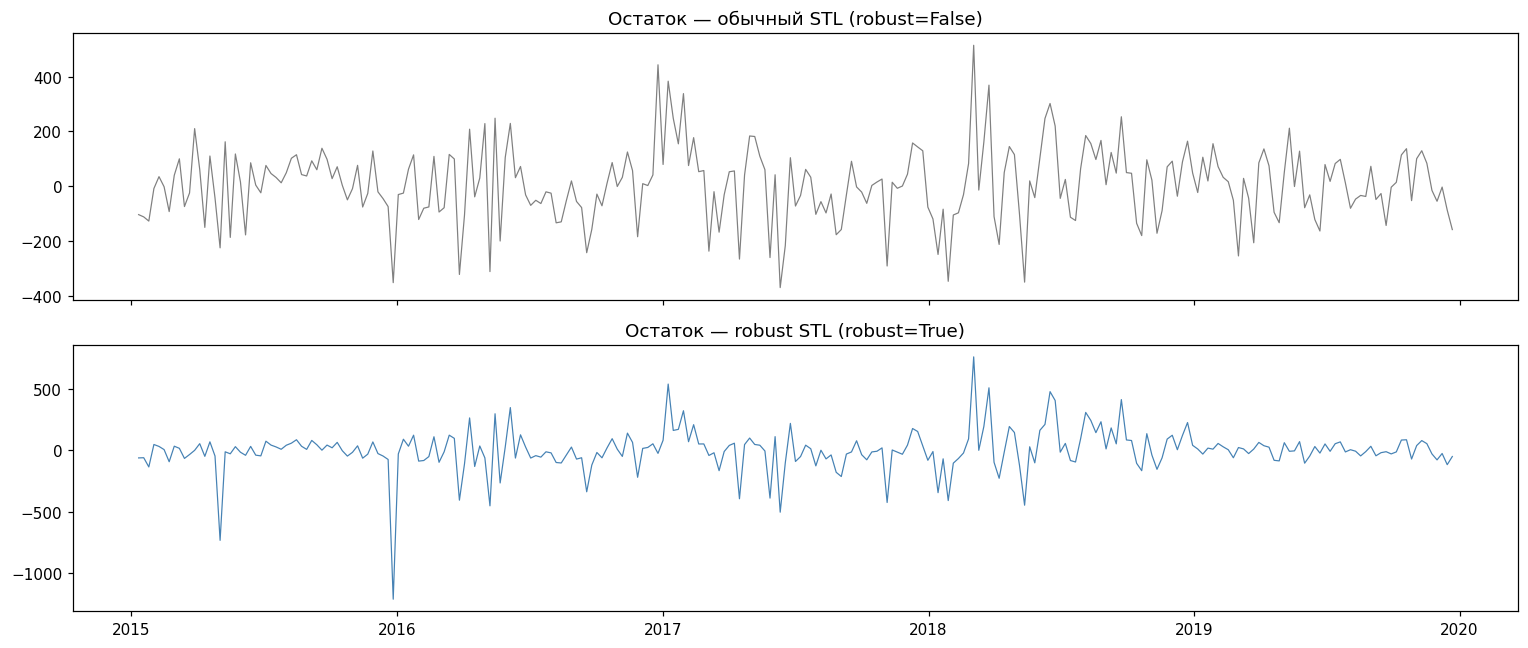

Обратите внимание: robust STL уменьшает влияние выбросов на оценку сезонности


In [10]:
# --- ЧТО ДАЁТ robust=True? ---
# Сравним обычный STL и robust STL на Consumption

col = 'Consumption'

stl_normal = STL(y[col], period=52, robust=False).fit()
stl_robust = STL(y[col], period=52, robust=True).fit()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(y.index, stl_normal.resid, lw=0.8, color='gray')
axes[0].set_title('Остаток — обычный STL (robust=False)')
axes[1].plot(y.index, stl_robust.resid, lw=0.8, color='steelblue')
axes[1].set_title('Остаток — robust STL (robust=True)')
plt.tight_layout()
plt.show()
print("Обратите внимание: robust STL уменьшает влияние выбросов на оценку сезонности")

---
## Метод 5 — CUSUM (Cumulative Sum)

**Идея:** отслеживать накопленное отклонение от целевого уровня $\mu_0$.  
Используется для детекции **устойчивых сдвигов** в среднем — не точечных выбросов, а длящихся аномалий.

$$C_t^+ = \max(0,\; C_{t-1}^+ + (y_t - \mu_0) - k)$$
$$C_t^- = \max(0,\; C_{t-1}^- - (y_t - \mu_0) - k)$$

Аномалия: $C_t^+ > h$ или $C_t^- > h$, где:
- $k$ — slack (обычно $0.5 \cdot \sigma$)
- $h$ — порог тревоги (обычно $4{-}5 \cdot \sigma$)

In [11]:
def cusum_anomalies(
    series: pd.Series,
    k_sigma: float = 0.5,
    h_sigma: float = 4.0,
    train_ratio: float = 0.5
) -> pd.DataFrame:
    """
    CUSUM детектор устойчивых сдвигов.

    Параметры
    ----------
    series      : pd.Series
    k_sigma     : slack как доля σ (обычно 0.5)
    h_sigma     : порог тревоги как доля σ (обычно 4-5)
    train_ratio : доля ряда для оценки μ₀ и σ
    """
    vals    = series.values
    n_train = int(len(vals) * train_ratio)

    mu0   = vals[:n_train].mean()
    sigma = vals[:n_train].std()
    k     = k_sigma * sigma
    h     = h_sigma * sigma

    # рассчитываем CUSUM
    C_pos = np.zeros(len(vals))
    C_neg = np.zeros(len(vals))

    for t in range(1, len(vals)):
        C_pos[t] = max(0, C_pos[t-1] + (vals[t] - mu0) - k)
        C_neg[t] = max(0, C_neg[t-1] - (vals[t] - mu0) - k)

    anomaly = ((C_pos > h) | (C_neg > h)).astype(int)

    return pd.DataFrame({
        'y':       series.values,
        'C_pos':   C_pos,
        'C_neg':   C_neg,
        'h':       h,
        'anomaly': anomaly
    }, index=series.index)


cusum_res = {col: cusum_anomalies(y[col], k_sigma=0.5, h_sigma=4.0) for col in ts}

for col, r in cusum_res.items():
    print(f"{col}: {r['anomaly'].sum()} аномальных точек")

Consumption: 134 аномальных точек
Wind: 153 аномальных точек
Solar: 214 аномальных точек


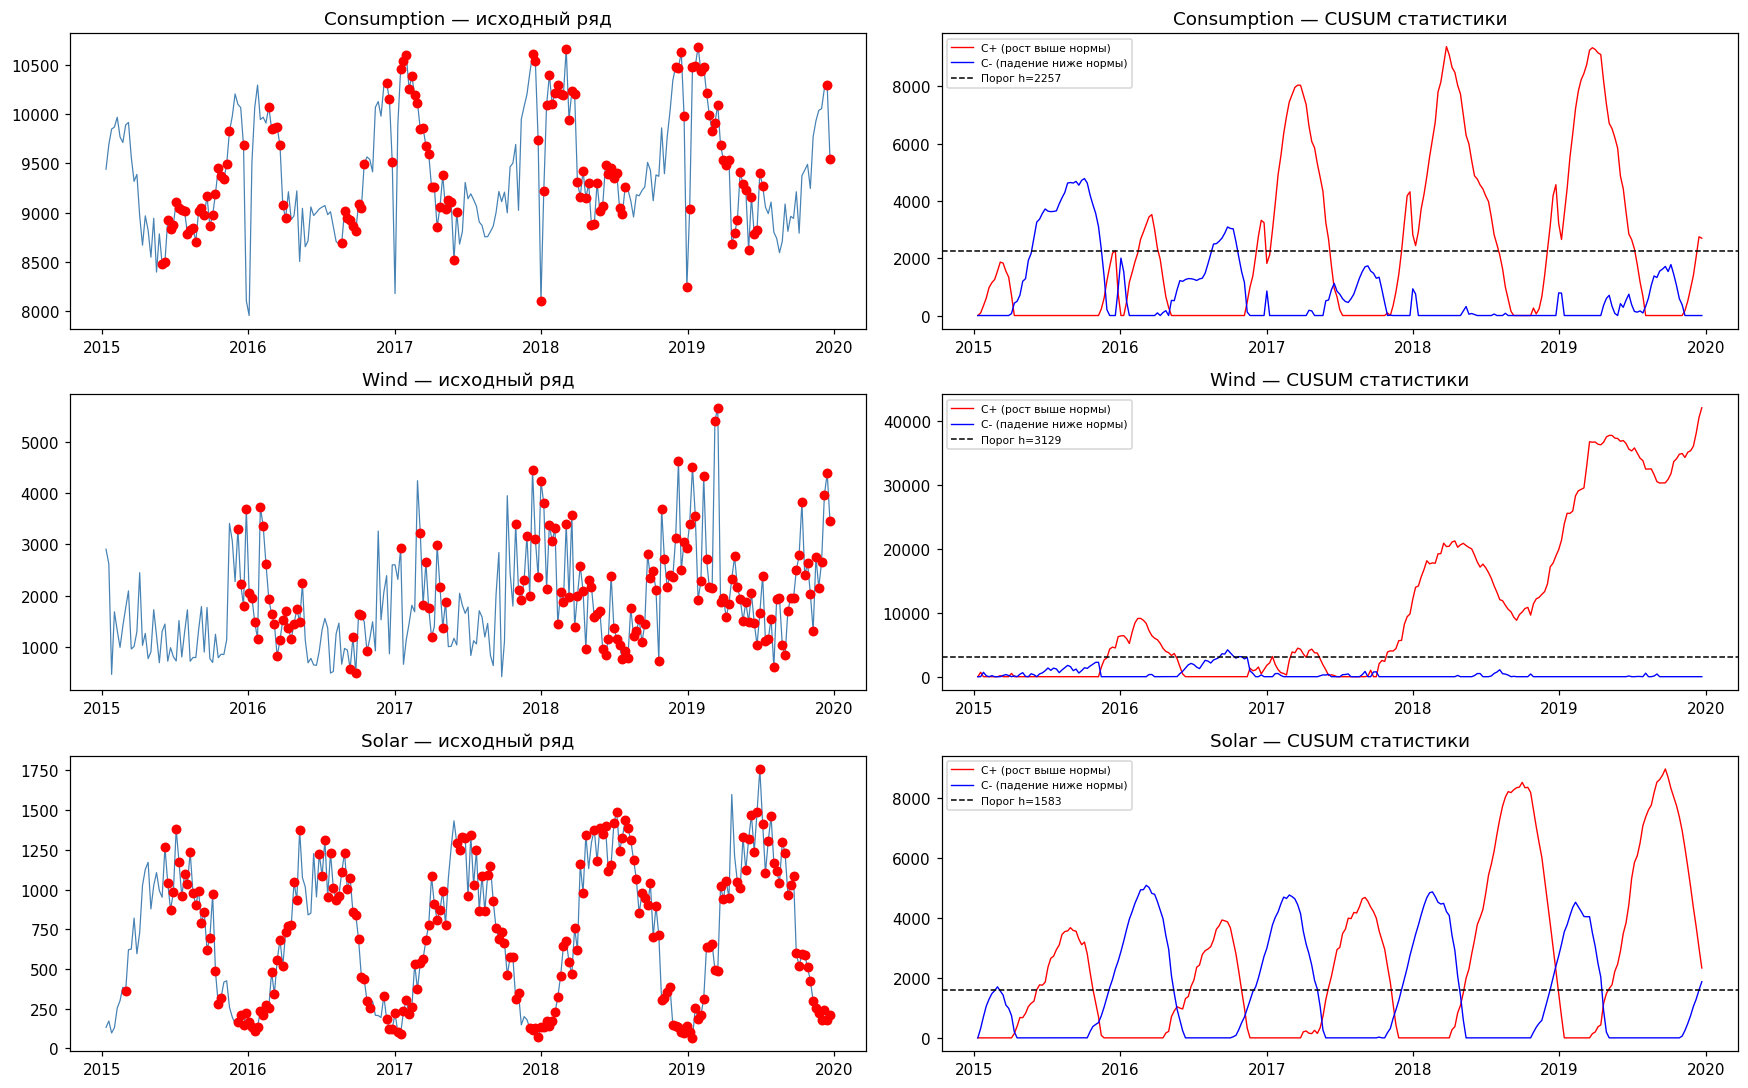

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, col in enumerate(ts):
    r = cusum_res[col]
    anom = r[r['anomaly'] == 1]

    # левая: исходный ряд
    ax = axes[i][0]
    ax.plot(r.index, r['y'], lw=0.8, color='steelblue')
    ax.scatter(anom.index, anom['y'], color='red', s=30, zorder=5)
    ax.set_title(f'{col} — исходный ряд')

    # правая: CUSUM-статистики
    ax2 = axes[i][1]
    ax2.plot(r.index, r['C_pos'], color='red',   lw=0.9, label='C+ (рост выше нормы)')
    ax2.plot(r.index, r['C_neg'], color='blue',  lw=0.9, label='C- (падение ниже нормы)')
    ax2.axhline(r['h'].iloc[0], color='black', ls='--', lw=1, label=f'Порог h={r["h"].iloc[0]:.0f}')
    ax2.set_title(f'{col} — CUSUM статистики')
    ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig('method5_cusum.png', dpi=120)
plt.show()

---
## Метод 6 — Тест Граббса (Grubbs Test)

**Идея:** формальный статистический тест на одну аномалию.  
Нулевая гипотеза $H_0$: в выборке нет аномалий.  
Статистика:

$$G = \frac{\max_i |y_i - \bar{y}|}{s}$$

Если $G > G_{crit}$ (из t-распределения при уровне $\alpha$) — самое далёкое значение является аномалией, оно удаляется, и тест повторяется итеративно.

**Ограничение:** работает строго с нормально распределёнными данными. Перед применением — проверить ряд остатков после STL.

In [13]:
def grubbs_test(
    series: pd.Series,
    alpha: float = 0.05,
    max_outliers: int = 20
) -> pd.DataFrame:
    """
    Итеративный тест Граббса (Extreme Studentized Deviate).

    Параметры
    ----------
    series       : pd.Series (лучше применять к STL-остатку)
    alpha        : уровень значимости (0.05 или 0.01)
    max_outliers : максимальное число итераций
    """
    vals      = series.copy()
    anomaly   = pd.Series(0, index=series.index)
    n_removed = 0

    for _ in range(max_outliers):
        n  = len(vals.dropna())
        if n < 3:
            break

        mu, sig = vals.mean(), vals.std()
        if sig == 0:
            break

        G_stat = (vals - mu).abs().max() / sig
        idx_max = (vals - mu).abs().idxmax()

        # критическое значение из t-распределения
        t_crit = stats.t.ppf(1 - alpha / (2 * n), df=n - 2)
        G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

        if G_stat > G_crit:
            anomaly[idx_max] = 1
            vals[idx_max]    = np.nan   # убираем аномалию и повторяем
            n_removed += 1
        else:
            break   # нет значимых выбросов → стоп

    return pd.DataFrame({'y': series, 'anomaly': anomaly})


# Важно: Grubbs лучше применять к STL-остатку (он ближе к нормальному)
grubbs_res = {}
for col in ts:
    residual = stl_res[col]['residual']   # остаток из Метода 4
    gr = grubbs_test(residual, alpha=0.05)
    # прикрепляем обратно к исходным значениям
    gr['y'] = y[col]
    grubbs_res[col] = gr
    print(f"{col}: {gr['anomaly'].sum()} аномалий")

Consumption: 7 аномалий
Wind: 3 аномалий
Solar: 8 аномалий


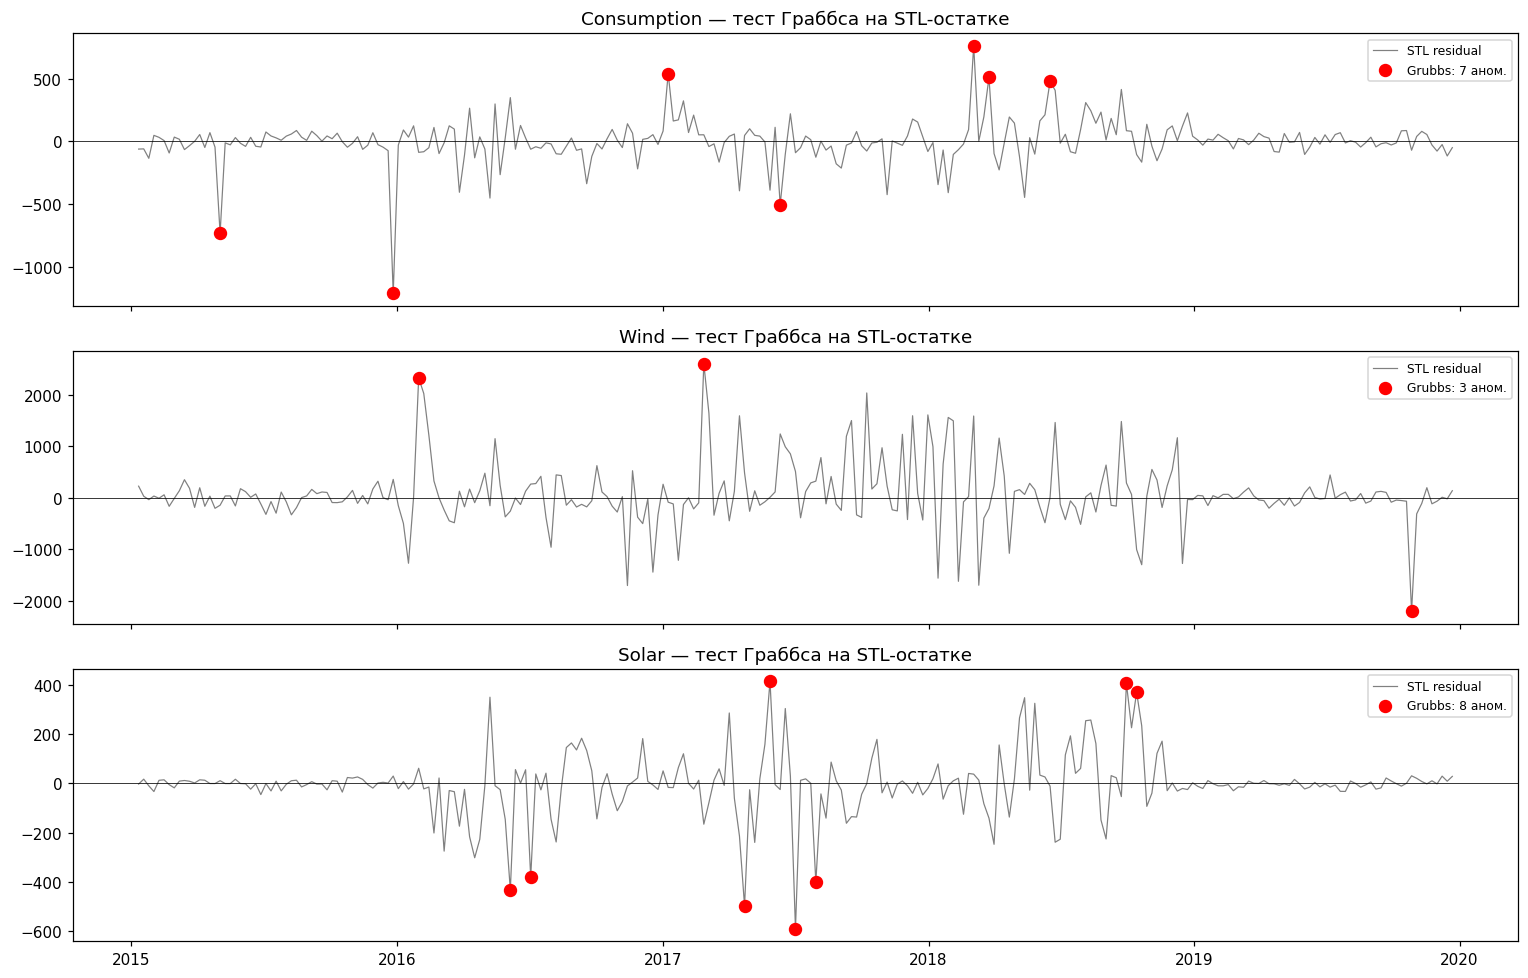

In [14]:
# Визуализация Grubbs: смотрим на остаток + помеченные точки
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, col in zip(axes, ts):
    resid = stl_res[col]['residual']
    ax.plot(resid.index, resid, lw=0.8, color='gray', label='STL residual')
    anom_idx = grubbs_res[col][grubbs_res[col]['anomaly'] == 1].index
    ax.scatter(anom_idx, resid.loc[anom_idx], color='red', s=60, zorder=5,
               label=f'Grubbs: {len(anom_idx)} аном.')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{col} — тест Граббса на STL-остатке')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('method6_grubbs.png', dpi=120)
plt.show()

---
## 7. Сравнение методов

### 7.1 Сводная таблица

In [15]:
def jaccard(a: set, b: set) -> float:
    """Коэффициент сходства Жаккара: |A∩B| / |A∪B|"""
    if not a and not b:
        return 1.0
    return round(len(a & b) / len(a | b), 3)


# --- собираем метки всех методов ---
def get_anomaly_set(df_method, col):
    """Вернуть set дат, где anomaly==1 для конкретного ряда."""
    r = df_method[col]
    return set(r[r['anomaly'] == 1].index)


method_dicts = {
    'ZScore':  zscore_res,
    'IQR':     iqr_res,
    'STL':     stl_res,
    'CUSUM':   cusum_res,
    'Grubbs':  grubbs_res,
}

# MSTL бейслайн
mstl_sets = {
    col: set(anomalies[anomalies['unique_id'] == col]['ds'])
    for col in ts
}

n_total = len(y)

for col in ts:
    print(f"\n{'='*58}")
    print(f"  {col}  (всего точек: {n_total})")
    print(f"{'='*58}")
    print(f"  {'Метод':<10} {'Аном-й':>8} {'%':>6}  {'Jaccard с MSTL':>15}")
    print(f"  {'-'*50}")

    # MSTL бейслайн
    ms = mstl_sets[col]
    print(f"  {'MSTL':<10} {len(ms):>8} {len(ms)/n_total*100:>5.1f}%  {'(baseline)':>15}")

    for name, d in method_dicts.items():
        s   = get_anomaly_set(d, col)
        cnt = len(s)
        pct = cnt / n_total * 100
        j   = jaccard(ms, s)
        print(f"  {name:<10} {cnt:>8} {pct:>5.1f}%  {j:>15.3f}")


  Consumption  (всего точек: 259)
  Метод        Аном-й      %   Jaccard с MSTL
  --------------------------------------------------
  MSTL             11   4.2%       (baseline)
  ZScore           13   5.0%            0.043
  IQR               8   3.1%            0.056
  STL               4   1.5%            0.154
  CUSUM           134  51.7%            0.074
  Grubbs            7   2.7%            0.200

  Wind  (всего точек: 259)
  Метод        Аном-й      %   Jaccard с MSTL
  --------------------------------------------------
  MSTL              8   3.1%       (baseline)
  ZScore            8   3.1%            0.231
  IQR               3   1.2%            0.100
  STL               5   1.9%            0.300
  CUSUM           153  59.1%            0.032
  Grubbs            3   1.2%            0.222

  Solar  (всего точек: 259)
  Метод        Аном-й      %   Jaccard с MSTL
  --------------------------------------------------
  MSTL             22   8.5%       (baseline)
  ZScore     

### 7.2 Ансамблирование: голосование

In [16]:
ensemble_res = {}

for col in ts:
    # объединяем метки всех методов в один DataFrame
    vote = pd.DataFrame(index=y.index)

    # MSTL
    vote['MSTL'] = y.index.isin(mstl_sets[col]).astype(int)

    for name, d in method_dicts.items():
        s = get_anomaly_set(d, col)
        vote[name] = y.index.isin(s).astype(int)

    vote['votes'] = vote.sum(axis=1)

    # разные пороги голосования
    for k in [2, 3, 4]:
        vote[f'ensemble_k{k}'] = (vote['votes'] >= k).astype(int)

    ensemble_res[col] = vote

    print(f"\n{col}:")
    for k in [2, 3, 4]:
        n = vote[f'ensemble_k{k}'].sum()
        print(f"  k>={k}: {n} аномалий ({n/n_total*100:.1f}%)")


Consumption:
  k>=2: 23 аномалий (8.9%)
  k>=3: 4 аномалий (1.5%)
  k>=4: 2 аномалий (0.8%)

Wind:
  k>=2: 13 аномалий (5.0%)
  k>=3: 6 аномалий (2.3%)
  k>=4: 2 аномалий (0.8%)

Solar:
  k>=2: 41 аномалий (15.8%)
  k>=3: 9 аномалий (3.5%)
  k>=4: 1 аномалий (0.4%)


### 7.3 Итоговый график — все методы на одном

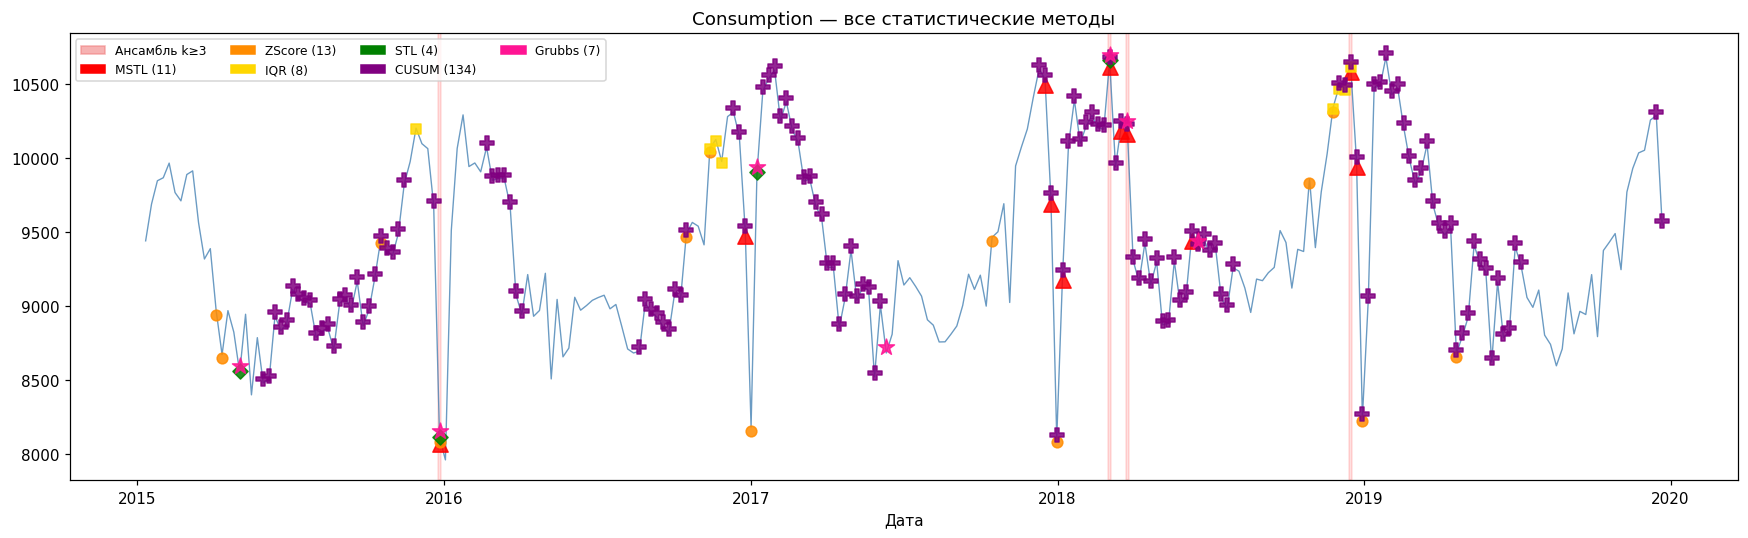

Сохранено: final_comparison_consumption.png


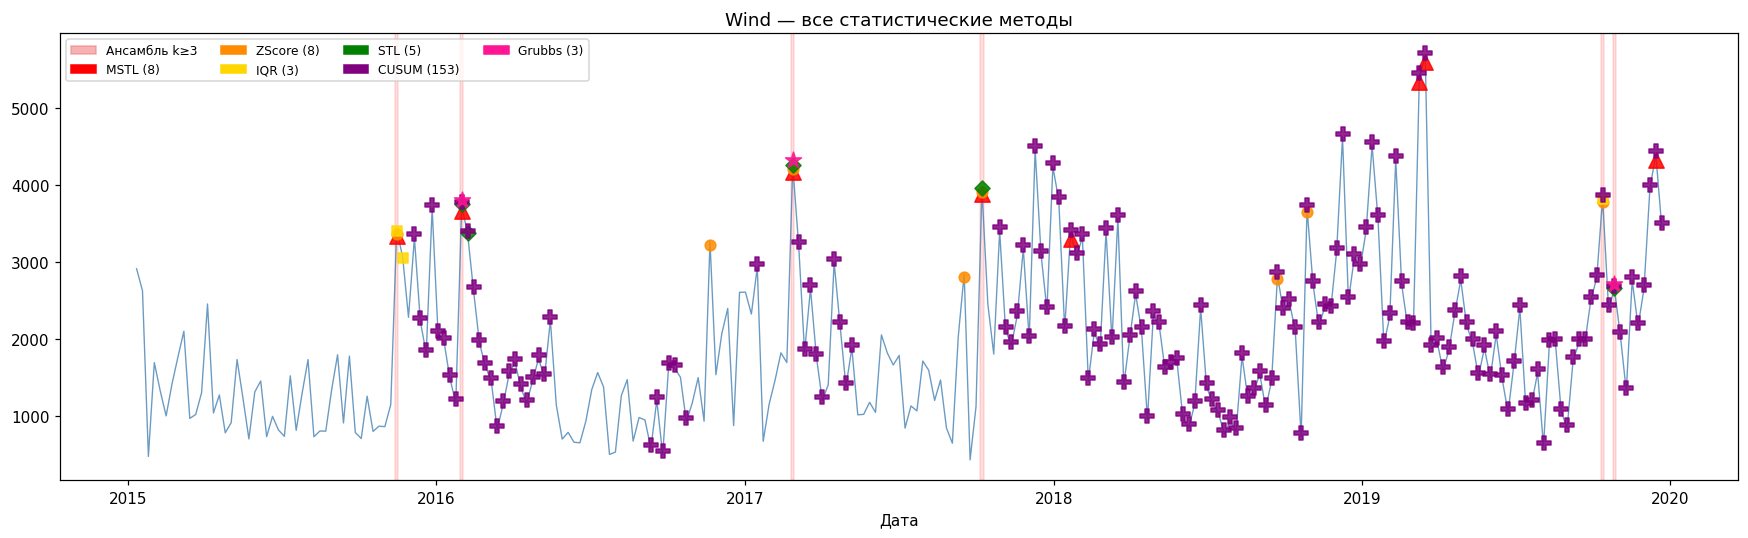

Сохранено: final_comparison_wind.png


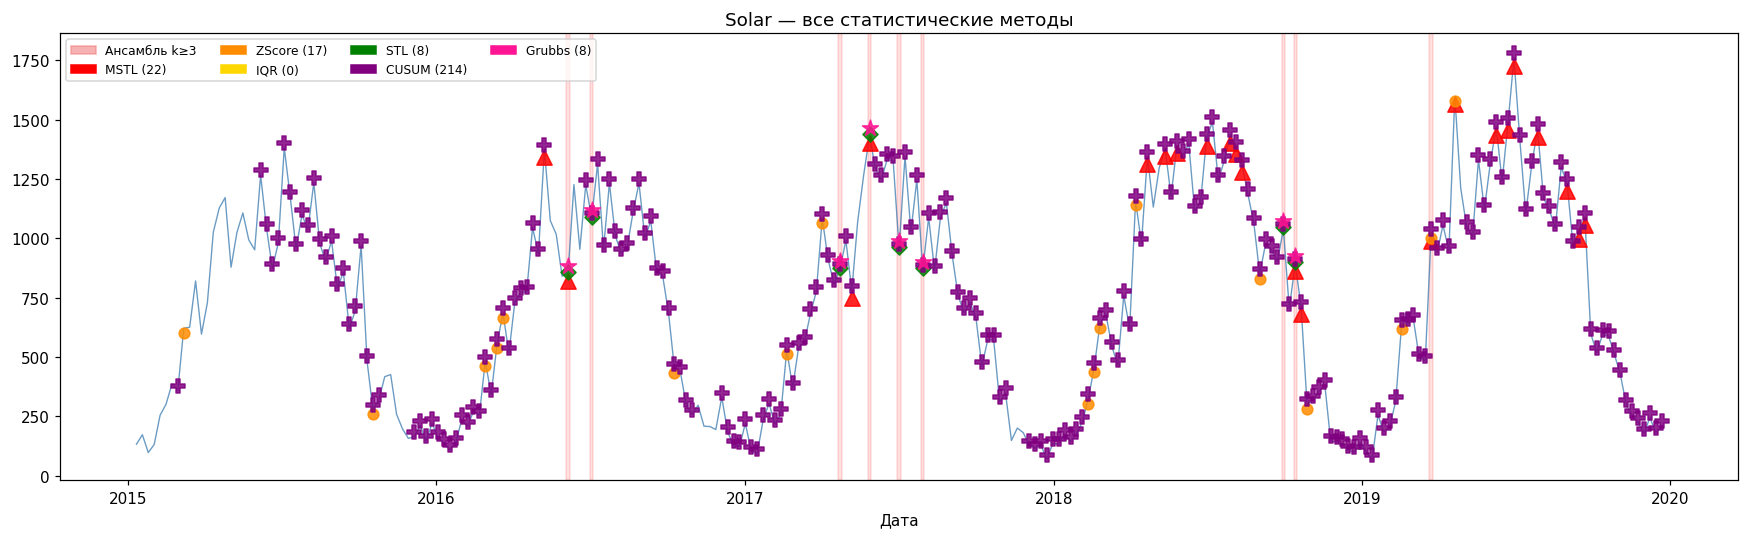

Сохранено: final_comparison_solar.png


In [17]:
COLORS = {
    'MSTL':   ('red',        '^', 10),
    'ZScore': ('darkorange', 'o', 7),
    'IQR':    ('gold',       's', 7),
    'STL':    ('green',      'D', 7),
    'CUSUM':  ('purple',     'P', 9),
    'Grubbs': ('deeppink',   '*', 11),
}

for col in ts:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y[col], lw=0.9, color='steelblue', zorder=1, alpha=0.8)

    # фоновая заливка для ансамблевых аномалий (k>=3)
    ev = ensemble_res[col]
    for t in y.index[ev['ensemble_k3'] == 1]:
        ax.axvspan(t - pd.Timedelta(days=2), t + pd.Timedelta(days=2),
                   alpha=0.12, color='red', zorder=0)

    handles = [mpatches.Patch(color='lightcoral', alpha=0.6, label='Ансамбль k≥3')]

    all_methods = {'MSTL': mstl_sets[col]}
    all_methods.update({n: get_anomaly_set(d, col) for n, d in method_dicts.items()})

    for i, (method, anom_dates) in enumerate(all_methods.items()):
        color, marker, ms = COLORS[method]
        vals = y.loc[list(anom_dates & set(y.index)), col]
        shift = (i - 2.5) * y[col].std() * 0.03
        ax.scatter(vals.index, vals + shift,
                   color=color, marker=marker, s=ms**2,
                   zorder=5 + i, alpha=0.85)
        handles.append(mpatches.Patch(color=color, label=f'{method} ({len(anom_dates)})'))

    ax.legend(handles=handles, fontsize=8, loc='upper left', ncol=4)
    ax.set_title(f'{col} — все статистические методы', fontsize=12)
    ax.set_xlabel('Дата')
    plt.tight_layout()
    plt.savefig(f'final_comparison_{col.lower()}.png', dpi=130)
    plt.show()
    print(f"Сохранено: final_comparison_{col.lower()}.png")

---
## 8. Задания для студентов

### Обязательные

**Задание 1. Влияние параметров (Rolling Z-score)**  
Заполните таблицу: запустите `rolling_zscore` для `Consumption` со всеми комбинациями:

```python
windows    = [4, 13, 26]
thresholds = [2.5, 3.0, 3.5]
```
Итого 9 экспериментов. Для каждого запишите количество аномалий.  
Вывод: какая комбинация даёт ближайший результат к MSTL-бейслайну?

---

**Задание 2. STL vs Rolling Z-score на Solar**  
Почему Rolling Z-score находит больше аномалий на ряде `Solar`, чем STL?  
Постройте два графика рядом и объясните разницу словами.

---

**Задание 3. Проверка нормальности остатков (для теста Граббса)**  
Тест Граббса предполагает нормальное распределение. Проверьте гипотезу:

```python
from scipy.stats import shapiro, normaltest
resid = stl_res['Consumption']['residual']
print(shapiro(resid))       # тест Шапиро-Уилка
print(normaltest(resid))    # тест Д'Агостино-Пирсона
```
Постройте Q-Q plot (`scipy.stats.probplot`). Нормален ли остаток?

---

**Задание 4. Интерпретация топ-5 аномалий**  
Найдите 5 дат, в которых наибольшее число методов одновременно фиксирует аномалию:  
```python
ensemble_res['Consumption'].sort_values('votes', ascending=False).head(10)
```
Для каждой даты: укажите значение ряда, сколько методов её нашли и предложите объяснение (COVID-19, экстремальные температуры, праздники и т.д.)

---

**Задание 5. CUSUM для сдвига уровня**  
Запустите `cusum_anomalies` с `h_sigma = 3.0, 4.0, 5.0`.  
На каком пороге CUSUM улавливает длительный период аномального потребления в 2020 году (COVID)?  
Объясните, чем CUSUM отличается от Z-score с точки зрения типа аномалии.

### Бонусные

**Бонус 1.** Реализуйте тест **Seasonal Hybrid ESD** (S-H-ESD, алгоритм Twitter):  
```python
!pip install pyculiarity
from pyculiarity import detect_ts
```

**Бонус 2.** Для ряда `Solar` сравните IQR-коридор, построенный глобально (на всём ряду) и в скользящем окне. Почему глобальный IQR не подходит?

**Бонус 3.** Реализуйте **modified Z-score** на основе медианы (MAD-score) — он устойчивее к выбросам:
$$M_t = \frac{0.6745 \cdot (y_t - \tilde{y})}{MAD}, \quad MAD = \text{median}(|y_i - \tilde{y}|)$$
Сравните с обычным Z-score на ряде `Wind`.